# TFT Forecaster v3 — Daily Store Revenue

Temporal Fusion Transformer improvements over v2:
- **RMSE loss** (penalizes large errors → reduces under-prediction of peaks)
- **Lag features** (7, 14, 28, 364 days) as time-varying unknown reals
- **Rolling statistics** (7-day and 28-day mean/std) as time-varying unknown reals
- **days_after_christmas** feature for post-holiday recovery pattern
- Larger model: `hidden_size=160`, `attention_head_size=8`
- Lower LR (5e-4), more epochs (80), less dropout (0.1)
- Christmas hard-coded to 0 post-prediction

**Run cells top-to-bottom.**

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Cell 1: Imports & GPU check
# ═══════════════════════════════════════════════════════════════════
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import RMSE

pl.seed_everything(42, workers=True)

print(f"PyTorch : {torch.__version__}")
print(f"Lightning: {pl.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device : {torch.cuda.get_device_name(0)}")
    print(f"  Version: {torch.version.cuda}")
    torch.set_float32_matmul_precision("medium")
else:
    print("⚠️  No GPU — training will be slow.")

Seed set to 42


PyTorch : 2.9.1+cu130
Lightning: 2.6.5
CUDA     : True
  Device : NVIDIA GeForce RTX 5080
  Version: 13.0


## 1. Data Preparation

In [2]:
# ═══════════════════════════════════════════════════════════════════
# Cell 2: Load data, build grid, engineer features
# ═══════════════════════════════════════════════════════════════════
TRAIN_PATH  = "train.csv"
EVENTS_PATH = "calendar_events.csv"

train  = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
events = pd.read_csv(EVENTS_PATH, parse_dates=["date"])

FORECAST_START = pd.Timestamp("2015-10-01")
FORECAST_END   = pd.Timestamp("2015-12-31")
HORIZON = (FORECAST_END - FORECAST_START).days + 1  # 92

print(f"Train : {train.shape}, {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Stores: {sorted(train['store_id'].unique())}")
print(f"Horizon: {HORIZON} days")

# --- Clean events: keep first event per date ---
events["event"] = events["event"].str.split(",").str[0].str.strip()
events_map = dict(zip(events["date"], events["event"]))

# --- State mapping: stores 1-4=CA, 5-7=TX, 8-10=WI, 0=ALL ---
STATE_MAP = {
    "0": "ALL",
    "1": "CA", "2": "CA", "3": "CA", "4": "CA",
    "5": "TX", "6": "TX", "7": "TX",
    "8": "WI", "9": "WI", "10": "WI",
}

# --- Key holiday dates ---
THANKSGIVING_2015 = pd.Timestamp("2015-11-26")
CHRISTMAS_2015    = pd.Timestamp("2015-12-25")

# --- Full (store × date) grid ---
date_min   = train["date"].min()
all_dates  = pd.date_range(date_min, FORECAST_END, freq="D")
all_stores = sorted(train["store_id"].unique())

grid = pd.MultiIndex.from_product(
    [all_stores, all_dates], names=["store_id", "date"]
).to_frame(index=False)

df = grid.merge(train[["store_id", "date", "revenue"]], on=["store_id", "date"], how="left")

# --- Time features (known-future) ---
df["dow"]        = df["date"].dt.dayofweek.astype(str)
df["month"]      = df["date"].dt.month.astype(str)
df["day"]        = df["date"].dt.day.astype(np.float32)
df["week"]       = df["date"].dt.isocalendar().week.astype(np.float32)
df["is_weekend"] = (df["date"].dt.dayofweek >= 5).astype(np.float32)

# Calendar event features
df["event"]    = df["date"].map(events_map).fillna("none").astype(str)
df["is_event"] = (df["event"] != "none").astype(np.float32)

# Holiday distance features
def days_to_holiday(date_series, holiday_month, holiday_day):
    years = date_series.dt.year
    holidays = pd.to_datetime(
        years.astype(str) + f"-{holiday_month:02d}-{holiday_day:02d}",
        errors="coerce"
    )
    delta = (holidays - date_series).dt.days.astype(np.float32)
    return delta.clip(lower=-30, upper=60)

df["days_to_christmas"] = days_to_holiday(df["date"], 12, 25)
df["days_to_thanksgiving"] = days_to_holiday(df["date"], 11, 25)

# Days AFTER Christmas — captures the post-holiday recovery/return pattern
def days_after_christmas(date_series):
    years = date_series.dt.year
    # For dates after Dec 25, use current year; for Jan dates, use prior year
    christmas_dates = pd.to_datetime(
        years.astype(str) + "-12-25", errors="coerce"
    )
    delta = (date_series - christmas_dates).dt.days.astype(np.float32)
    # Only positive values matter (days since last Christmas)
    # For dates before Christmas in same year, use prior year's Christmas
    prior_christmas = pd.to_datetime(
        (years - 1).astype(str) + "-12-25", errors="coerce"
    )
    delta_prior = (date_series - prior_christmas).dt.days.astype(np.float32)
    # Use the smaller positive value
    result = np.where(delta >= 0, delta, delta_prior)
    # Cap at 30 days — beyond that it's not relevant
    return np.clip(result, 0, 30).astype(np.float32)

df["days_after_christmas"] = days_after_christmas(df["date"])

# Integer time index
df["time_idx"] = (df["date"] - date_min).dt.days.astype(np.int64)

# Static categoricals
df["store_id"] = df["store_id"].astype(str)
df["state"]    = df["store_id"].map(STATE_MAP)

# Fill historical gaps (forward-fill per store); future = 0
mask_past = df["date"] < FORECAST_START
df.loc[mask_past, "revenue"] = (
    df.loc[mask_past].groupby("store_id")["revenue"].transform(lambda s: s.ffill().bfill())
)
df["revenue"] = df["revenue"].fillna(0.0).astype(np.float32)

# ─── LAG FEATURES (time-varying unknown — only known for the past) ───
for lag in [7, 14, 28, 364]:
    col = f"revenue_lag_{lag}"
    df[col] = df.groupby("store_id")["revenue"].shift(lag).astype(np.float32)

# ─── ROLLING STATISTICS (time-varying unknown) ───
for window in [7, 28]:
    mean_col = f"revenue_roll{window}_mean"
    std_col  = f"revenue_roll{window}_std"
    df[mean_col] = (
        df.groupby("store_id")["revenue"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
        .astype(np.float32)
    )
    df[std_col] = (
        df.groupby("store_id")["revenue"]
        .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        .astype(np.float32)
    )

# Fill any NaN from lags/rolling with 0 (early rows)
df = df.fillna(0.0)

print(f"\nGrid: {len(df):,} rows | {df['store_id'].nunique()} stores | "
      f"{df['date'].min().date()} → {df['date'].max().date()}")
print(df[["store_id", "state", "date", "revenue", "days_after_christmas"]].tail(10))

Train : (18766, 4), 2011-01-29 → 2015-09-30
Stores: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Horizon: 92 days

Grid: 19,778 rows | 11 stores | 2011-01-29 → 2015-12-31
      store_id state       date  revenue  days_after_christmas
19768       10    WI 2015-12-22      0.0                  30.0
19769       10    WI 2015-12-23      0.0                  30.0
19770       10    WI 2015-12-24      0.0                  30.0
19771       10    WI 2015-12-25      0.0                   0.0
19772       10    WI 2015-12-26      0.0                   1.0
19773       10    WI 2015-12-27      0.0                   2.0
19774       10    WI 2015-12-28      0.0                   3.0
19775       10    WI 2015-12-29      0.0                   4.0
19776       10    WI 2015-12-30      0.0                   5.0
19777       10    WI 2015-12-31      0.0                   6.0


## 2. Build TimeSeriesDataSet

- Encoder: **365 days**
- Decoder: **92 days**
- Static categoricals: `store_id`, `state`
- Known-future categoricals: `event`, `dow`, `month`
- Known-future reals: `time_idx`, `is_event`, `is_weekend`, `day`, `week`, `days_to_christmas`, `days_to_thanksgiving`, `days_after_christmas`
- Unknown reals: `revenue`, lag features, rolling statistics

In [3]:
# ═══════════════════════════════════════════════════════════════════
# Cell 3: TimeSeriesDataSet construction
# ═══════════════════════════════════════════════════════════════════
MAX_ENCODER_LENGTH    = 365
MAX_PREDICTION_LENGTH = HORIZON  # 92

training_cutoff = int(
    df.loc[df["date"] == FORECAST_START - pd.Timedelta(days=1), "time_idx"].iloc[0]
)
print(f"Training cutoff: time_idx={training_cutoff} "
      f"({df.loc[df['time_idx']==training_cutoff,'date'].iloc[0].date()})")

# Unknown reals: revenue + lags + rolling stats
unknown_reals = ["revenue"]
for lag in [7, 14, 28, 364]:
    unknown_reals.append(f"revenue_lag_{lag}")
for window in [7, 28]:
    unknown_reals.append(f"revenue_roll{window}_mean")
    unknown_reals.append(f"revenue_roll{window}_std")

print(f"Unknown reals: {unknown_reals}")

training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="revenue",
    group_ids=["store_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["store_id", "state"],
    time_varying_known_categoricals=["event", "dow", "month"],
    time_varying_known_reals=[
        "time_idx", "is_event", "is_weekend", "day", "week",
        "days_to_christmas", "days_to_thanksgiving", "days_after_christmas",
    ],
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=["store_id"], transformation="softplus"),
    categorical_encoders={
        "event": NaNLabelEncoder(add_nan=True),
        "dow":   NaNLabelEncoder(add_nan=True),
        "month": NaNLabelEncoder(add_nan=True),
        "state": NaNLabelEncoder(add_nan=True),
    },
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

BATCH_SIZE = 64
train_dataloader = training.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_dataloader   = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print(f"Training samples  : {len(training):,}")
print(f"Validation samples: {len(validation):,}")

Training cutoff: time_idx=1705 (2015-09-30)
Unknown reals: ['revenue', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_28', 'revenue_lag_364', 'revenue_roll7_mean', 'revenue_roll7_std', 'revenue_roll28_mean', 'revenue_roll28_std']
Training samples  : 13,750
Validation samples: 11


## 3. Configure & Train TFT

Key changes from v2:
- `loss=RMSE()` — penalizes large errors harder, reduces under-prediction bias
- `hidden_size=160`, `attention_head_size=8` — more capacity
- `dropout=0.1` — less regularization to reduce underfitting
- `learning_rate=5e-4` — slower, more precise convergence
- `max_epochs=80`, `patience=12`

In [4]:
# ═══════════════════════════════════════════════════════════════════
# Cell 4: Train the TFT
# ═══════════════════════════════════════════════════════════════════
early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=12, mode="min")
lr_monitor = LearningRateMonitor(logging_interval="epoch")

trainer = pl.Trainer(
    max_epochs=80,
    accelerator="auto",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_monitor],
    enable_progress_bar=True,
    log_every_n_steps=20,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=5e-4,
    hidden_size=160,
    attention_head_size=8,
    dropout=0.1,
    hidden_continuous_size=64,
    output_size=1,
    loss=RMSE(),
    log_interval=20,
    reduce_on_plateau_patience=5,
)

print(f"TFT parameters: {sum(p.numel() for p in tft.parameters()):,}")

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TFT parameters: 2,216,563


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ RMSE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    569 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 92.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  571 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  281 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  103 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  103 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  103 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  103 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  206 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  206 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 51.5 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    320 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  128 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 57.9 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 51.8 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  103 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 51.8 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    161 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 2.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.2 M                                                                                                
Total estimated model params size (MB): 8.866                                                                      
Modules in train mode: 647                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

## 4. Generate Predictions

In [5]:
# ═══════════════════════════════════════════════════════════════════
# Cell 5: Predict 2015-10-01 → 2015-12-31
# ═══════════════════════════════════════════════════════════════════
best_ckpt = trainer.checkpoint_callback.best_model_path if trainer.checkpoint_callback else ""
if best_ckpt:
    print(f"Loading best checkpoint: {best_ckpt}")
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
else:
    print("No checkpoint — using final model.")
    best_tft = tft

out = best_tft.predict(
    val_dataloader,
    mode="prediction",
    return_x=True,
    return_index=True,
)
preds = out.output.cpu().numpy()
if preds.ndim == 3:
    preds = preds.squeeze(-1)
index = out.index.reset_index(drop=True)

print(f"Predictions shape: {preds.shape}")

Loading best checkpoint: C:\Users\Guy\Documents\M.S. MLDS\Advanced ML\FinalProject\AdvancedML_Project\DeepLearning\lightning_logs\version_4\checkpoints\epoch=46-step=10058.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predictions shape: (11, 92)


## 5. Build Submission

Post-processing:
- Clip predictions ≥ 0
- **Hard-code Dec 25 = 0** for all stores

In [6]:
# ═══════════════════════════════════════════════════════════════════
# Cell 6: Assemble submission CSV
# ═══════════════════════════════════════════════════════════════════
records = []
for i, row in index.iterrows():
    store_id = row["store_id"]
    start_idx = int(row["time_idx"])
    for j in range(preds.shape[1]):
        date = date_min + pd.Timedelta(days=start_idx + j)
        records.append({
            "store_id": store_id,
            "date": date,
            "prediction": float(preds[i, j]),
        })

submission_long = pd.DataFrame(records)

# Post-processing
submission_long["prediction"] = submission_long["prediction"].clip(lower=0)

# Hard-code Christmas Day = 0
christmas_mask = submission_long["date"] == CHRISTMAS_2015
submission_long.loc[christmas_mask, "prediction"] = 0.0
print(f"Christmas override: {christmas_mask.sum()} rows set to 0")

# Format for submission
submission = submission_long.copy()
submission["id"] = (
    submission["store_id"].astype(str) + "_" + submission["date"].dt.strftime("%Y%m%d")
)
submission = submission[["id", "prediction"]]

expected = len(all_stores) * HORIZON
print(f"Submission rows: {len(submission)} (expected {expected})")
print(submission.head())
print(submission.tail())

Christmas override: 11 rows set to 0
Submission rows: 1012 (expected 1012)
           id   prediction
0  0_20151001  262169.1875
1  0_20151002  310559.6250
2  0_20151003  364993.2500
3  0_20151004  380167.1875
4  0_20151005  298254.0625
              id    prediction
1007  9_20151227  21013.609375
1008  9_20151228  20652.759766
1009  9_20151229  21206.654297
1010  9_20151230  21729.423828
1011  9_20151231  21393.523438


## 6. Plots — History vs Forecast

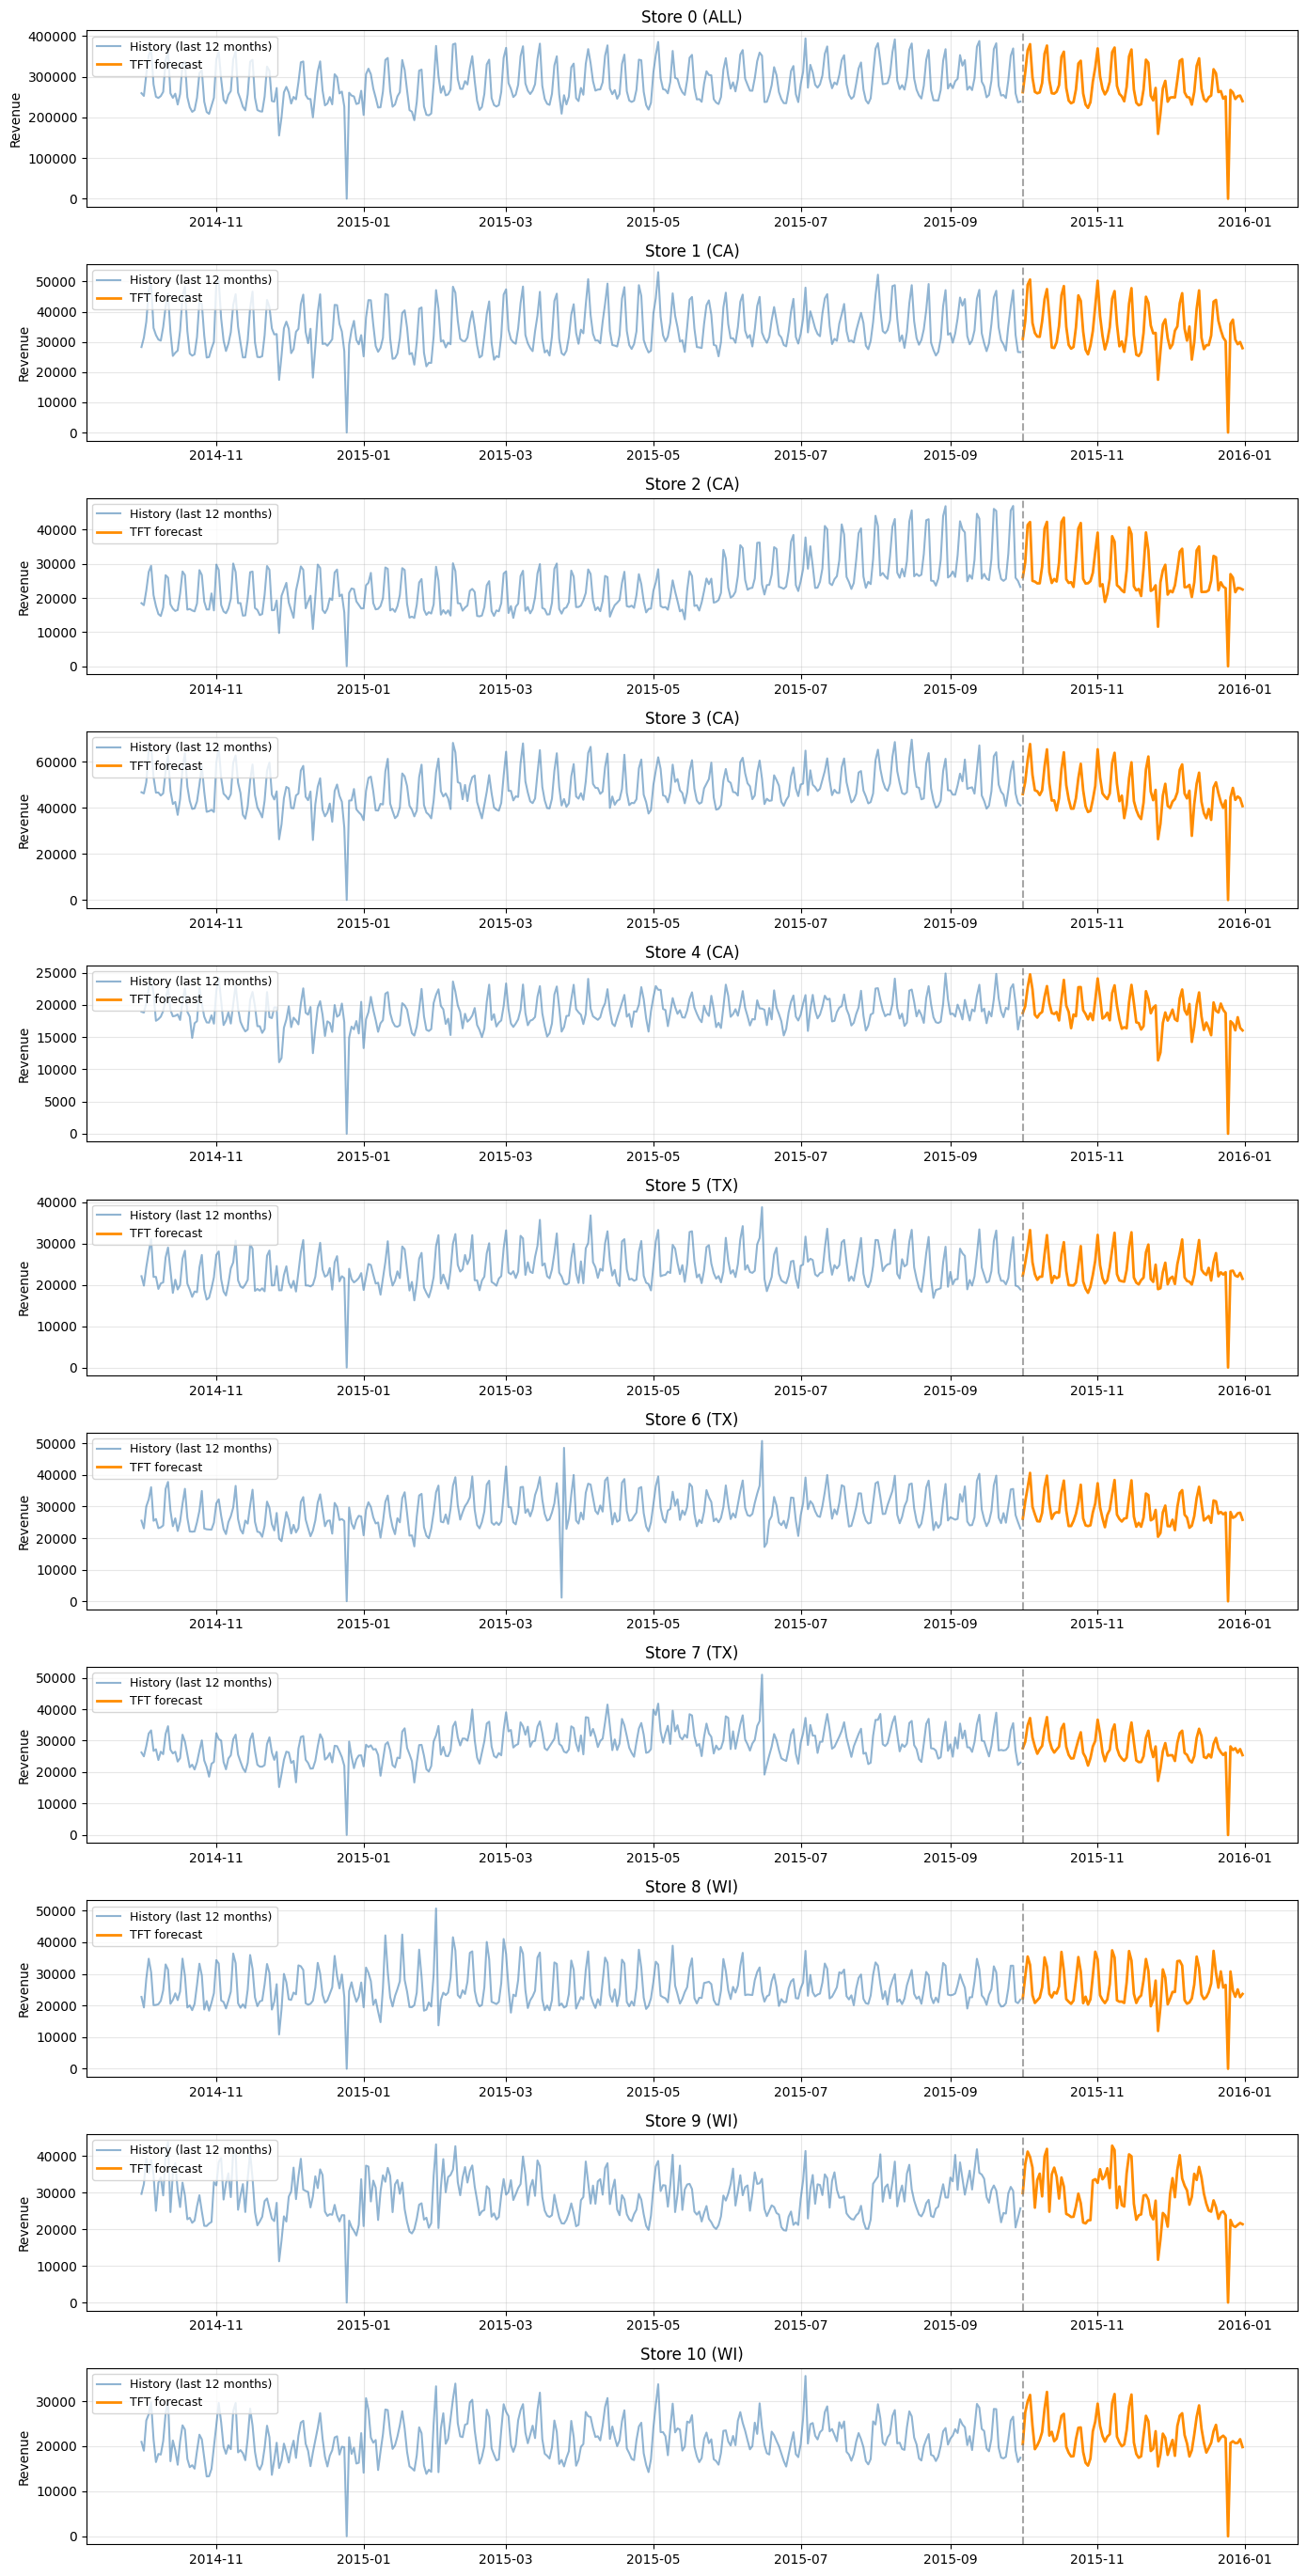

Saved: Results\forecast_plots.png


In [7]:
# ═══════════════════════════════════════════════════════════════════
# Cell 7: Visualization
# ═══════════════════════════════════════════════════════════════════
RESULTS_DIR = "Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

n = len(all_stores)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=False)
if n == 1:
    axes = [axes]

history_window = pd.Timedelta(days=365)
for ax, store_id in zip(axes, all_stores):
    store_str = str(store_id)
    hist = df[
        (df["store_id"] == store_str)
        & (df["date"] < FORECAST_START)
        & (df["date"] >= FORECAST_START - history_window)
    ]
    ax.plot(hist["date"], hist["revenue"], color="steelblue", alpha=0.6,
            label="History (last 12 months)")

    pred_rows = submission_long[submission_long["store_id"] == store_str].sort_values("date")
    ax.plot(pred_rows["date"], pred_rows["prediction"], color="darkorange",
            linewidth=2, label="TFT forecast")

    state = STATE_MAP.get(store_str, "")
    ax.axvline(FORECAST_START, linestyle="--", color="gray", alpha=0.7)
    ax.set_title(f"Store {store_id} ({state})")
    ax.set_ylabel("Revenue")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "forecast_plots.png")
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## 7. Export to `Results/`

In [8]:
# ═══════════════════════════════════════════════════════════════════
# Cell 8: Save results
# ═══════════════════════════════════════════════════════════════════
submission_path = os.path.join(RESULTS_DIR, "forecast_submission.csv")
submission.to_csv(submission_path, index=False)
print(f"✔ Submission : {submission_path} ({len(submission)} rows)")

long_path = os.path.join(RESULTS_DIR, "forecast_predictions_long.csv")
submission_long.to_csv(long_path, index=False)
print(f"✔ Long-form  : {long_path}")

✔ Submission : Results\forecast_submission.csv (1012 rows)
✔ Long-form  : Results\forecast_predictions_long.csv
